# Dos dosis antes de la quimio, y la neuropatía no apareció

126 días de seguimiento. Los ratones que recibieron dos dosis de psilocibina **antes** del cisplatino terminaron sin hipersensibilidad distinguible de la de los ratones que nunca recibieron quimio (p = 0,80, n = 4-5) — y con esas muestras, no distinguirse no es lo mismo que ser igual.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Heles et al. (2026). *Psilocybin prevents chemotherapy-induced peripheral neuropathy through mitochondrial trafficking preservation*. **Science**.

**DOI:** [10.1126/science.aec6116](https://doi.org/10.1126/science.aec6116)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-03-psilocibina-neuropatia-quimio/notebook.ipynb)

**Video:** [Pendiente]

## De qué estamos hablando

Si alguien cercano ha pasado por quimioterapia con platino, quizá conozcas esto sin saber su nombre: los dedos que se duermen, el vaso que se resbala, el pie que deja de sentir bien el piso. Se llama neuropatía periférica inducida por quimioterapia (CIPN), afecta a millones de pacientes, muchas veces no se va, y no tiene tratamiento probado. Es una de las razones por las que a veces hay que bajarle la dosis a un tratamiento que está salvando una vida.

Lo que este equipo probó es contraintuitivo: dar psilocibina —el compuesto de los hongos— **antes** de la quimio, como escudo, no después como calmante. La midieron en ratones, en neuronas sensoriales humanas cultivadas desde células madre (iSNs) y en tejido humano ex vivo. Cero pacientes tratados con psilocibina en este estudio.

Los datos que vamos a abrir son las tablas suplementarias del propio artículo: la conducta de los ratones día por día, la agudeza táctil, las fibras nerviosas de la piel y las mitocondrias dentro de los axones.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DOSIS_MG_KG      = 1      # mg/kg de psilocibina por dosis
N_DOSIS_ESCUDO   = 2      # dosis previas que previenen del todo
DIAS_SEGUIMIENTO = 126    # duración del seguimiento conductual
CONTROL_TAPE     = 100    # el test de la cinta va normalizado al control

COLOR_DATOS      = '#2563EB'   # azul CaM — psilocibina + quimio
COLOR_ALERTA     = '#DC2626'   # rojo — quimio sola
COLOR_REFERENCIA = '#D97706'   # ámbar — dosis intermedia
COLOR_SECUNDARIO = '#059669'   # verde — psilocibina sola
COLOR_CONTEXTO   = '#8A8A8A'   # gris — sin quimio

FUENTE = ('Fuente: Heles et al. (2026), Science | '
          'Datos: tablas suplementarias S6-S9 del mismo artículo')

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
# Vista previa embebida más liviana (el contenedor tiene 256 MB).
# Las figuras se SIGUEN guardando a dpi=200 vía savefig.
plt.rcParams['figure.dpi'] = 90

os.makedirs('figuras', exist_ok=True)

# Descarga automática de los CSV si no están junto al notebook
ARCHIVOS = ['von_frey_dias.csv', 'tape_test_pre_post.csv',
            'ienfd_por_grupo.csv', 'vdac_axonal.csv', 'acetona_frio.csv']
os.makedirs('datos', exist_ok=True)
for archivo in ARCHIVOS:
    destino = f'datos/{archivo}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(
            f'{BASE}/papers/2026-09-03-psilocibina-neuropatia-quimio/datos/{archivo}',
            destino)

vf     = pd.read_csv('datos/von_frey_dias.csv')        # conducta, por ratón y día
tape   = pd.read_csv('datos/tape_test_pre_post.csv')   # agudeza táctil, pareado
ienfd  = pd.read_csv('datos/ienfd_por_grupo.csv')      # fibras nerviosas de la piel
vdac   = pd.read_csv('datos/vdac_axonal.csv')          # mitocondria dentro del axón
frio   = pd.read_csv('datos/acetona_frio.csv')         # alodinia al frío


def cohens_d(a, b):
    """d de Cohen para dos grupos independientes (pooled)."""
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2)
                / (na + nb - 2))
    return (b.mean() - a.mean()) / s


dias = [int(d) for d in sorted(vf.dia.unique())]
print(f'von Frey      : {len(vf):3d} filas | '
      f'{vf.groupby("grupo").raton.nunique().min()}-{vf.groupby("grupo").raton.nunique().max()} '
      f'ratones por grupo | días {dias}')
print(f'cinta adhesiva: {len(tape):3d} filas | {tape.grupo.nunique()} brazos experimentales')
print(f'fibras (IENFD): {len(ienfd):3d} filas | condiciones: {list(ienfd.condicion.unique())}')
print(f'VDAC axonal   : {len(vdac):3d} axones | grupos: {list(vdac.grupo.unique())}')
print(f'acetona (frío): {len(frio):3d} filas | {frio.grupo.nunique()} grupos x n=6')
print()
print('Unidades: von Frey y acetona = score adimensional (mayor = más dolor).')
print('          cinta = % respecto al control (mayor = peor tacto).')
print('          IENFD = fibras por mm de epidermis. VDAC = µm² por célula.')

von Frey      : 190 filas | 4-5 ratones por grupo | días [0, 9, 18, 26, 40, 57, 74, 95, 109, 126]
cinta adhesiva:  42 filas | 7 brazos experimentales
fibras (IENFD):  55 filas | condiciones: ['1_semana_7mgkg', '4_semanas_23mgkg']
VDAC axonal   : 100 axones | grupos: ['VEH', 'CIS', 'PSI+CIS', 'PSI']
acetona (frío):  24 filas | 4 grupos x n=6

Unidades: von Frey y acetona = score adimensional (mayor = más dolor).
          cinta = % respecto al control (mayor = peor tacto).
          IENFD = fibras por mm de epidermis. VDAC = µm² por célula.


## Aquí está.

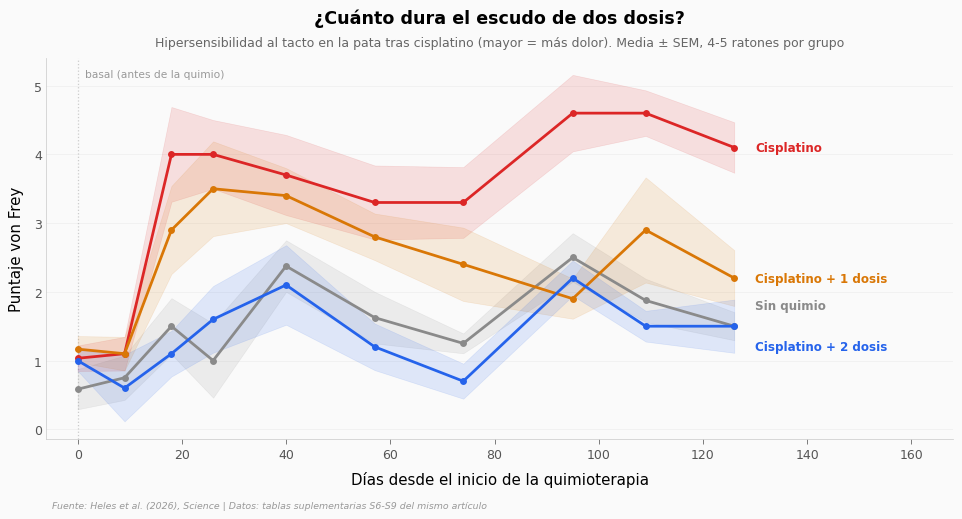

Media post-basal por ratón (días 9-126):
  Sin quimio             n=4  media=1.60
  Cisplatino             n=5  media=3.63
  Cisplatino + 1 dosis   n=5  media=2.57
  Cisplatino + 2 dosis   n=5  media=1.39

  Sin quimio vs Cisplatino: p=0.0195, d=3.33  -> la quimio sí hace daño
  Cisplatino vs Cisplatino + 1 dosis: p=0.0937, d=1.56  -> una dosis: protección parcial
  Cisplatino vs Cisplatino + 2 dosis: p=0.0117, d=4.36  -> dos dosis
  Sin quimio vs Cisplatino + 2 dosis: p=0.8049, d=0.55  -> dos dosis vs no recibir quimio


In [2]:
# Hipersensibilidad mecánica (von Frey) a lo largo de 126 días
ORDEN_VF = ['No treatment', 'Cisplatin', 'Cisplatin + Psi 1D', 'Cisplatin + Psi 2D']
ETIQUETA_VF = {
    'No treatment':       ('Sin quimio',           COLOR_CONTEXTO),
    'Cisplatin':          ('Cisplatino',           COLOR_ALERTA),
    'Cisplatin + Psi 1D': ('Cisplatino + 1 dosis', COLOR_REFERENCIA),
    'Cisplatin + Psi 2D': ('Cisplatino + 2 dosis', COLOR_DATOS),
}

# Los grupos "sin quimio" y "2 dosis" terminan en el mismo valor: separamos
# sus etiquetas a mano para que no se pisen.
OFFSET_ETIQUETA = {'No treatment': 0.30, 'Cisplatin + Psi 2D': -0.30}

fig, ax = plt.subplots(figsize=(13, 5.5))

for grupo in ORDEN_VF:
    sub = vf[vf.grupo == grupo]
    curva = sub.groupby('dia').vf_score.agg(['mean', 'sem'])
    etiqueta, color = ETIQUETA_VF[grupo]
    ax.plot(curva.index, curva['mean'], color=color, linewidth=2.2,
            marker='o', markersize=4.5, zorder=5)
    ax.fill_between(curva.index, curva['mean'] - curva['sem'],
                    curva['mean'] + curva['sem'], color=color, alpha=0.13, zorder=3)
    # Inline label al final de cada curva (reemplaza la caja de leyenda)
    ax.text(DIAS_SEGUIMIENTO + 4, curva['mean'].iloc[-1] + OFFSET_ETIQUETA.get(grupo, 0),
            etiqueta, fontsize=9.5, color=color, fontweight='bold', va='center')

ax.axvline(x=0, color='#CCCCCC', linewidth=1, linestyle=':')
ax.text(1.5, ax.get_ylim()[1] * 0.97, 'basal (antes de la quimio)',
        fontsize=8.5, color='#999999', va='top')

ax.set_title('¿Cuánto dura el escudo de dos dosis?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Hipersensibilidad al tacto en la pata tras cisplatino '
        '(mayor = más dolor). Media ± SEM, 4-5 ratones por grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Días desde el inicio de la quimioterapia')
ax.set_ylabel('Puntaje von Frey')
ax.set_xlim(-6, 168)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/von_frey_126_dias.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

# Estadística sobre la media post-basal de cada ratón (días 9-126)
post = (vf[vf.dia > 0].groupby(['grupo', 'raton']).vf_score.mean()
        .reset_index())
g = lambda k: post[post.grupo == k].vf_score

print('Media post-basal por ratón (días 9-126):')
for k in ORDEN_VF:
    print(f'  {ETIQUETA_VF[k][0]:22s} n={len(g(k))}  media={g(k).mean():.2f}')
print()
for a, b, nota in [('No treatment', 'Cisplatin', 'la quimio sí hace daño'),
                   ('Cisplatin', 'Cisplatin + Psi 1D', 'una dosis: protección parcial'),
                   ('Cisplatin', 'Cisplatin + Psi 2D', 'dos dosis'),
                   ('No treatment', 'Cisplatin + Psi 2D', 'dos dosis vs no recibir quimio')]:
    # El grupo Cisplatino no pasa Shapiro-Wilk (p = 0,015) y n = 4-5:
    # test no paramétrico. Ojo: el paper usa ANOVA + Tukey, estos p no son los suyos.
    U, p = stats.mannwhitneyu(g(a), g(b), alternative='two-sided')
    print(f'  {ETIQUETA_VF[a][0]} vs {ETIQUETA_VF[b][0]}: '
          f'p={p:.4f}, d={abs(cohens_d(g(a), g(b))):.2f}  -> {nota}')

### Lo que llama la atención

El cisplatino despega en la tercera semana —el día 9 los cuatro grupos siguen juntos, el día 18 ya no— y de ahí no vuelve a bajar. Promediando todo lo que viene después del basal, queda en 3,63 contra 1,60 de los ratones sin quimio (d de Cohen 3,33, p = 0,020). Con **una** dosis previa de psilocibina la hipersensibilidad baja a 2,57 —mitigación, no prevención—. Con **dos**, se queda en 1,39, y ahí deja de distinguirse de no haber recibido quimio del todo (p = 0,80).

Ojo con esa última frase: "no se distingue" no es lo mismo que "es igual". Con 4 y 5 ratones por grupo, un p alto es ausencia de evidencia, no evidencia de equivalencia. Lo que sí sostienen los datos es la gradación 0 → 1 → 2 dosis, y hay que leerla en el agregado de los 126 días. Día por día el ruido es considerable: incluso los ratones sin quimio suben y bajan, y en el día 95 una dosis llega a quedar por debajo de dos (1,90 vs 2,20) — el único cruce en los nueve días de seguimiento.

Y la dosis en el ratón es pequeña: 1 mg/kg, dos veces, antes de empezar. Qué significaría eso en una persona es otra pregunta, y este estudio no la responde.

## ¿Dónde está actuando, en la cabeza o en la pata?

La psilocibina llega al cerebro —de eso trata toda su fama—. Pero la neuropatía ocurre en los nervios de las patas. Las dos cosas no pueden ser la misma historia.

El equipo las separó bloqueando el receptor 5HT2A (la puerta por donde entra la psilocibina) de dos maneras: **sistémica**, con ketanserina en todo el cuerpo, o **intracerebroventricular (ICV)**, inyectada directo al cerebro y solo ahí. Si el escudo se cae únicamente cuando el bloqueo alcanza la periferia, la protección del tacto necesita el receptor de fuera del cerebro. Ojo con el salto fácil: eso no deja al cerebro fuera de la historia — el propio artículo describe mecanismos centrales *y* periféricos, y mide cambios en la corteza prefrontal.

La medida es el test de la cinta adhesiva: cuánto tarda el ratón en quitarse un adhesivo pegado a la pata. Más tiempo, peor tacto. Todo normalizado al grupo control, que vale 100.

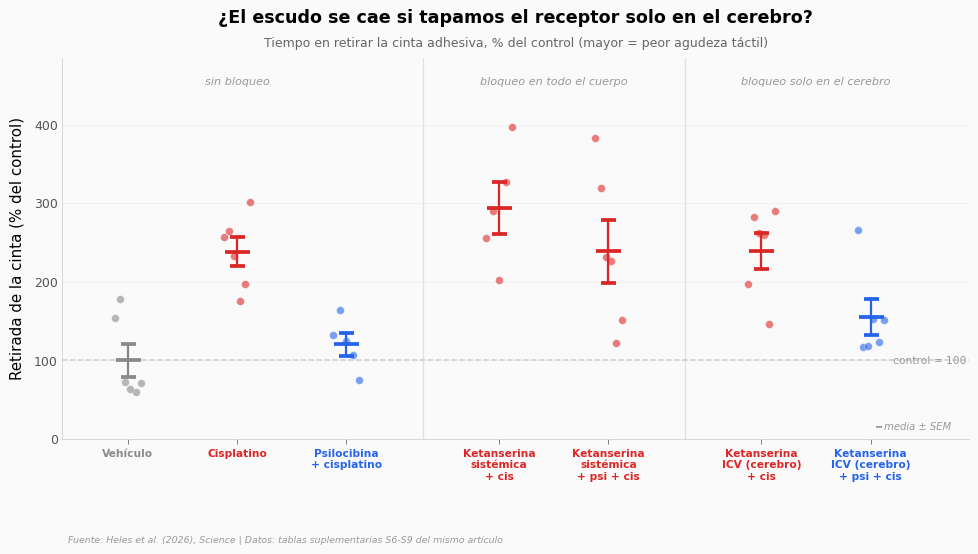

Medias del valor post (% del control):
  Vehículo                               n=6  media=100.00
  Cisplatino                             n=6  media=238.32
  Psilocibina + cisplatino               n=5  media=120.73
  Ketanserina sistémica + cis            n=5  media=294.35
  Ketanserina sistémica + psi + cis      n=6  media=238.82
  Ketanserina ICV (cerebro) + cis        n=6  media=239.59
  Ketanserina ICV (cerebro) + psi + cis  n=6  media=154.87

  Vehicle vs Cisplatin: p=0.0043, d=2.81  -> la quimio empeora el tacto
  Cisplatin vs Psi + Cis: p=0.0043, d=2.89  -> la psilocibina lo protege
  Psi + Cis vs Ket + Psi + Cis: p=0.0519, d=1.54  -> bloqueo sistémico: el escudo se cae
  Cisplatin vs Ket + Psi + Cis: p=0.8182, d=0.01  -> con bloqueo sistémico queda igual que la quimio sola
  Psi + Cis vs ICV-Ket + Psi + Cis: p=0.5368, d=0.72  -> bloqueo solo cerebral: el escudo aguanta


In [3]:
# Agudeza táctil (cinta adhesiva) por brazo experimental — valores post
ORDEN_TAPE = ['Vehicle', 'Cisplatin', 'Psi + Cis',
              'Ket + Cis', 'Ket + Psi + Cis',
              'ICV-Ket + Cis', 'ICV-Ket + Psi + Cis']
ETIQUETA_TAPE = ['Vehículo', 'Cisplatino', 'Psilocibina\n+ cisplatino',
                 'Ketanserina\nsistémica\n+ cis', 'Ketanserina\nsistémica\n+ psi + cis',
                 'Ketanserina\nICV (cerebro)\n+ cis', 'Ketanserina\nICV (cerebro)\n+ psi + cis']
COLORES_TAPE = [COLOR_CONTEXTO, COLOR_ALERTA, COLOR_DATOS,
                COLOR_ALERTA, COLOR_ALERTA,
                COLOR_ALERTA, COLOR_DATOS]
POSICIONES = [0, 1, 2, 3.4, 4.4, 5.8, 6.8]

fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

for pos, grupo, color in zip(POSICIONES, ORDEN_TAPE, COLORES_TAPE):
    vals = tape[tape.grupo == grupo].att_pct_post.dropna().values
    n = len(vals)
    x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=40, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=20,
                markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

Y_TOPE = tape.att_pct_post.max() * 1.22
ax.set_ylim(0, Y_TOPE)

ax.axhline(y=CONTROL_TAPE, color='#CCCCCC', linewidth=1.2, linestyle='--', zorder=2)
ax.set_xlim(-0.6, 7.7)
ax.text(7.0, CONTROL_TAPE, 'control = 100', fontsize=8.5, color='#999999',
        ha='left', va='center')

# Separadores entre bloques experimentales
for x in (2.7, 5.1):
    ax.axvline(x=x, color='#E0E0E0', linewidth=1, zorder=1)
for x, texto in [(1.0, 'sin bloqueo'), (3.9, 'bloqueo en todo el cuerpo'),
                 (6.3, 'bloqueo solo en el cerebro')]:
    ax.text(x, Y_TOPE * 0.95, texto, fontsize=9, color='#999999',
            ha='center', va='top', style='italic')

ax.set_xticks(POSICIONES)
ax.set_xticklabels(ETIQUETA_TAPE, fontsize=8.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), COLORES_TAPE):
    tick.set_color(color)
ax.set_title('¿El escudo se cae si tapamos el receptor solo en el cerebro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tiempo en retirar la cinta adhesiva, % del control '
        '(mayor = peor agudeza táctil)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Retirada de la cinta (% del control)')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.10, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cinta_adhesiva_ketanserina.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

t = lambda k: tape[tape.grupo == k].att_pct_post.dropna()
print('Medias del valor post (% del control):')
for k, e in zip(ORDEN_TAPE, ETIQUETA_TAPE):
    print(f'  {e.replace(chr(10), " "):38s} n={len(t(k))}  media={t(k).mean():6.2f}')
print()
for a, b, nota in [
        ('Vehicle', 'Cisplatin', 'la quimio empeora el tacto'),
        ('Cisplatin', 'Psi + Cis', 'la psilocibina lo protege'),
        ('Psi + Cis', 'Ket + Psi + Cis', 'bloqueo sistémico: el escudo se cae'),
        ('Cisplatin', 'Ket + Psi + Cis', 'con bloqueo sistémico queda igual que la quimio sola'),
        ('Psi + Cis', 'ICV-Ket + Psi + Cis', 'bloqueo solo cerebral: el escudo aguanta')]:
    # Vehículo e ICV-Ket + Psi + Cis no pasan Shapiro-Wilk (p = 0,026 y 0,010)
    U, p = stats.mannwhitneyu(t(a), t(b), alternative='two-sided')
    print(f'  {a} vs {b}: p={p:.4f}, d={abs(cohens_d(t(a), t(b))):.2f}  -> {nota}')

## ¿Y el nervio? ¿Se ve algo en el tejido?

Que el ratón se comporte distinto no dice si el nervio está dañado o si solo cambió cómo el sistema lo lee. Para eso hay que contar fibras: la densidad de terminaciones nerviosas que llegan hasta la epidermis (IENFD), lo mismo que se mide en una biopsia de piel de un paciente.

Aquí hay que separar dos experimentos que parecen el mismo y no lo son: **una semana** con la dosis estándar de cisplatino (7 mg/kg) y **cuatro semanas** con la dosis acumulada alta (23 mg/kg). Tiempos y dosis distintos, resultados distintos.

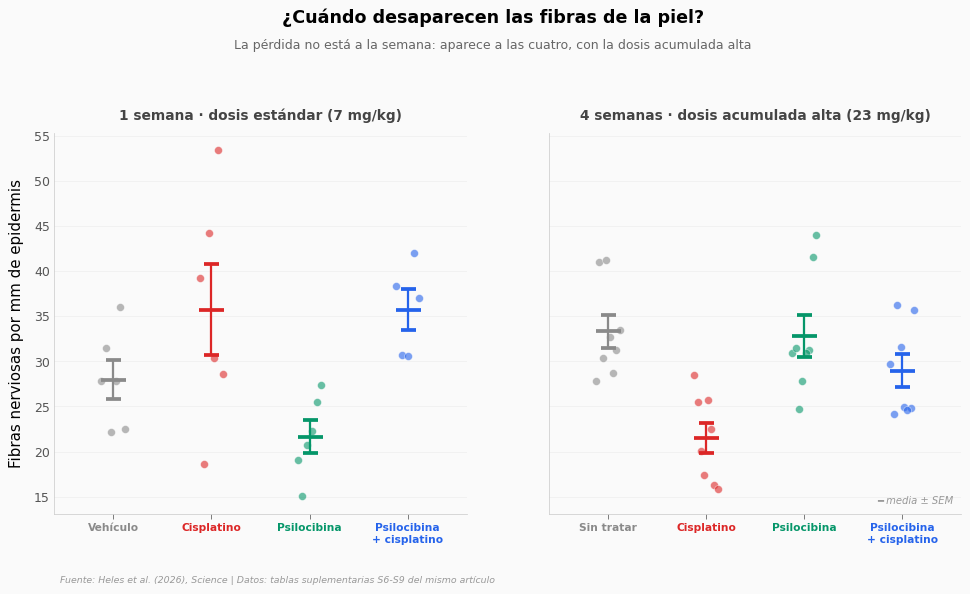

1 semana · dosis estándar (7 mg/kg)
  Vehicle    n=6  media= 27.97  IQR=[23.84, 30.59]
  Cis        n=6  media= 35.72  IQR=[29.04, 42.93]
  Psi        n=6  media= 21.65  IQR=[19.48, 24.67]
  Psi+Cis    n=5  media= 35.74  IQR=[30.74, 38.32]
  ANOVA de una vía: F=4.59, p=0.0141

4 semanas · dosis acumulada alta (23 mg/kg)
  Naive      n=8  media= 33.31  IQR=[29.97, 35.38]
  Cis        n=8  media= 21.49  IQR=[17.12, 25.55]
  Psi        n=8  media= 32.84  IQR=[30.12, 34.02]
  Psi + Cis  n=8  media= 28.96  IQR=[24.75, 32.62]
  ANOVA de una vía: F=8.04, p=0.0005

  4 semanas · Naive vs Cis: -35.5%, p=0.0003, d=2.37
  4 semanas · Cis vs Psi + Cis: +34.8%, p=0.0091, d=1.51
  4 semanas · Naive vs Psi + Cis: -13.1%, p=0.1114, d=0.85

  Brecha recuperada por la psilocibina: 63% del hueco que abrió el cisplatino


In [4]:
# Densidad de fibras nerviosas intraepidérmicas: 1 semana vs 4 semanas
PANELES = [
    ('1_semana_7mgkg', '1 semana · dosis estándar (7 mg/kg)',
     ['Vehicle', 'Cis', 'Psi', 'Psi+Cis'],
     ['Vehículo', 'Cisplatino', 'Psilocibina', 'Psilocibina\n+ cisplatino']),
    ('4_semanas_23mgkg', '4 semanas · dosis acumulada alta (23 mg/kg)',
     ['Naive', 'Cis', 'Psi', 'Psi + Cis'],
     ['Sin tratar', 'Cisplatino', 'Psilocibina', 'Psilocibina\n+ cisplatino']),
]
COLORES_IENFD = [COLOR_CONTEXTO, COLOR_ALERTA, COLOR_SECUNDARIO, COLOR_DATOS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
np.random.seed(42)

for ax, (cond, titulo, grupos, etiquetas) in zip(axes, PANELES):
    sub = ienfd[ienfd.condicion == cond]
    for i, (grupo, color) in enumerate(zip(grupos, COLORES_IENFD)):
        vals = sub[sub.grupo == grupo].ienfd_fibras_por_mm.values
        n = len(vals)
        x_strip = np.linspace(i - 0.12, i + 0.12, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=40, alpha=0.6,
                   edgecolors='white', linewidths=0.5, zorder=5)
        media = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(i, media, yerr=sem, fmt='_', color=color, markersize=20,
                    markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.set_xticks(range(len(grupos)))
    ax.set_xticklabels(etiquetas, fontsize=8.5, fontweight='bold')
    for tick, color in zip(ax.get_xticklabels(), COLORES_IENFD):
        tick.set_color(color)
    ax.set_title(titulo, fontsize=11, color='#444444', pad=10)
    ax.set_xlim(-0.6, len(grupos) - 0.4)

axes[0].set_ylabel('Fibras nerviosas por mm de epidermis')
axes[1].text(0.98, 0.02, '━ media ± SEM', transform=axes[1].transAxes, fontsize=8,
             color='#999999', ha='right', va='bottom', style='italic')
fig.suptitle('¿Cuándo desaparecen las fibras de la piel?', fontsize=14,
             fontweight='bold', y=1.13)
fig.text(0.5, 1.05, 'La pérdida no está a la semana: aparece a las cuatro, '
         'con la dosis acumulada alta',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fibras_piel_1sem_vs_4sem.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

for cond, titulo, grupos, _ in PANELES:
    sub = ienfd[ienfd.condicion == cond]
    f = lambda k: sub[sub.grupo == k].ienfd_fibras_por_mm
    print(titulo)
    for k in grupos:
        q1, q3 = np.percentile(f(k), [25, 75])
        print(f'  {k:10s} n={len(f(k))}  media={f(k).mean():6.2f}  '
              f'IQR=[{q1:.2f}, {q3:.2f}]')
    F, p = stats.f_oneway(*[f(k) for k in grupos])
    print(f'  ANOVA de una vía: F={F:.2f}, p={p:.4f}')
    print()

s4 = ienfd[ienfd.condicion == '4_semanas_23mgkg']
h = lambda k: s4[s4.grupo == k].ienfd_fibras_por_mm
for a, b in [('Naive', 'Cis'), ('Cis', 'Psi + Cis'), ('Naive', 'Psi + Cis')]:
    _, p = stats.ttest_ind(h(a), h(b))
    delta = (h(b).mean() - h(a).mean()) / h(a).mean() * 100
    print(f'  4 semanas · {a} vs {b}: {delta:+.1f}%, p={p:.4f}, '
          f'd={abs(cohens_d(h(a), h(b))):.2f}')

brecha = (h("Psi + Cis").mean() - h("Cis").mean()) / (h("Naive").mean() - h("Cis").mean()) * 100
print(f'\n  Brecha recuperada por la psilocibina: {brecha:.0f}% del hueco que abrió el cisplatino')

## El sospechoso: la mitocondria que no llega a la punta

¿Por qué se pierde la fibra? La explicación que propone el equipo es de logística, no de energía. El axón de una neurona sensorial es larguísimo, y las mitocondrias tienen que viajar hasta la punta para alimentarla. Si el transporte se traba, la punta se queda sin suministro y se retira.

Esto lo midieron en el sistema humano del paper: neuronas sensoriales derivadas de células iPS. VDAC marca mitocondria, y el área de señal **dentro del axón** dice cuánta mitocondria llegó hasta ahí.

Un detalle que cambia cómo hay que leer la gráfica: la distribución está muy sesgada hacia la derecha (asimetría entre 1,2 y 1,9 según el grupo). Con ese sesgo la media miente —en el grupo control queda casi encima de su propio cuartil superior—, así que aquí manda la mediana.

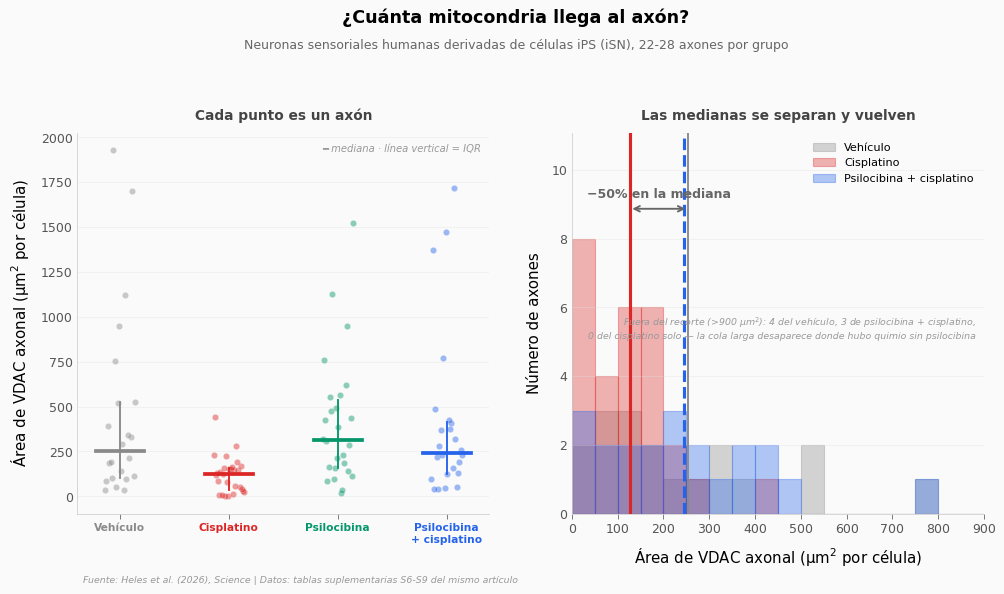

Mediana e IQR por grupo (µm2 por célula):
  Vehículo                   n=22  mediana= 253.5  IQR=[103.5, 525.0]  asimetría=1.65
  Cisplatino                 n=28  mediana= 126.5  IQR=[37.3, 158.0]  asimetría=1.17
  Psilocibina                n=26  mediana= 315.0  IQR=[159.5, 539.0]  asimetría=1.49
  Psilocibina + cisplatino   n=24  mediana= 244.0  IQR=[127.2, 414.5]  asimetría=1.81

Kruskal-Wallis (4 grupos): H=19.08, p=0.00026
  Mann-Whitney VEH vs CIS: -50.1% en mediana, U=460.5, p=0.00297
  Mann-Whitney CIS vs PSI+CIS: +92.9% en mediana, U=155.0, p=0.00092
  Mann-Whitney VEH vs PSI+CIS: -3.7% en mediana, U=264.0, p=1.00000


In [5]:
# Mitocondria dentro del axón (VDAC) en neuronas sensoriales humanas iSN
ORDEN_VDAC = ['VEH', 'CIS', 'PSI', 'PSI+CIS']
ETIQUETA_VDAC = ['Vehículo', 'Cisplatino', 'Psilocibina', 'Psilocibina\n+ cisplatino']
COLORES_VDAC = [COLOR_CONTEXTO, COLOR_ALERTA, COLOR_SECUNDARIO, COLOR_DATOS]

v = lambda k: vdac[vdac.grupo == k].vdac_area_um2_por_celula.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)

# Panel izquierdo — mediana e IQR por grupo (la distribución está sesgada)
ax = axes[0]
for i, (grupo, color) in enumerate(zip(ORDEN_VDAC, COLORES_VDAC)):
    vals = v(grupo)
    x_strip = np.linspace(i - 0.14, i + 0.14, len(vals))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=26, alpha=0.45,
               edgecolors='white', linewidths=0.4, zorder=5)
    q1, mediana, q3 = np.percentile(vals, [25, 50, 75])
    ax.plot([i - 0.22, i + 0.22], [mediana, mediana], color=color, linewidth=3, zorder=7)
    ax.plot([i, i], [q1, q3], color=color, linewidth=1.5, zorder=6)
ax.set_xticks(range(4))
ax.set_xticklabels(ETIQUETA_VDAC, fontsize=8.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), COLORES_VDAC):
    tick.set_color(color)
ax.set_ylabel('Área de VDAC axonal (µm$^2$ por célula)')
ax.set_title('Cada punto es un axón', fontsize=11, color='#444444', pad=10)
ax.text(0.98, 0.97, '━ mediana · línea vertical = IQR', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

# Panel derecho — distribución y distancia entre medianas.
# Recortamos el eje X en 900: la cola derecha llega a 1.930 y aplastaría
# la zona donde está el 90% de los axones. Los que quedan fuera se cuentan abajo.
ax = axes[1]
CORTE_X = 900
GRUPOS_HIST = [('VEH', COLOR_CONTEXTO, 'Vehículo'),
               ('CIS', COLOR_ALERTA, 'Cisplatino'),
               ('PSI+CIS', COLOR_DATOS, 'Psilocibina + cisplatino')]
bins = np.linspace(0, CORTE_X, 19)
for grupo, color, etiqueta in GRUPOS_HIST:
    vals = v(grupo)
    ax.hist(vals[vals <= CORTE_X], bins=bins, color=color, alpha=0.35,
            edgecolor=color, linewidth=0.9, label=etiqueta)
y_max = ax.get_ylim()[1] * 1.32
ax.set_ylim(0, y_max)
ax.set_xlim(0, CORTE_X)
fuera = {g: int((v(g) > CORTE_X).sum()) for g, _, _ in GRUPOS_HIST}
ax.text(0.98, 0.52, f'Fuera del recorte (>{CORTE_X} µm$^2$): '
        f'{fuera["VEH"]} del vehículo, {fuera["PSI+CIS"]} de psilocibina + cisplatino,\n'
        f'{fuera["CIS"]} del cisplatino solo — la cola larga desaparece donde hubo quimio sin psilocibina',
        transform=ax.transAxes, fontsize=7.5, color='#999999', ha='right', va='top',
        style='italic')
med_cis = np.median(v('CIS'))
med_veh = np.median(v('VEH'))
med_psi = np.median(v('PSI+CIS'))
ax.axvline(x=med_cis, color=COLOR_ALERTA, linewidth=2.5)
ax.axvline(x=med_veh, color=COLOR_CONTEXTO, linewidth=1.5)
ax.axvline(x=med_psi, color=COLOR_DATOS, linewidth=2.5, linestyle='--')
ax.annotate('', xy=(med_veh, y_max * 0.80), xytext=(med_cis, y_max * 0.80),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((med_cis + med_veh) / 2, y_max * 0.83,
        f'−{(1 - med_cis / med_veh) * 100:.0f}% en la mediana', fontsize=10,
        fontweight='bold', color='#666666', ha='center')
ax.set_xlabel('Área de VDAC axonal (µm$^2$ por célula)')
ax.set_ylabel('Número de axones')
ax.set_title('Las medianas se separan y vuelven', fontsize=11, color='#444444', pad=10)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.suptitle('¿Cuánta mitocondria llega al axón?', fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.05, 'Neuronas sensoriales humanas derivadas de células iPS (iSN), '
         '22-28 axones por grupo', fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mitocondria_axonal_vdac.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close('all')

print('Mediana e IQR por grupo (µm2 por célula):')
for k, e in zip(ORDEN_VDAC, ETIQUETA_VDAC):
    q1, mediana, q3 = np.percentile(v(k), [25, 50, 75])
    print(f'  {e.replace(chr(10), " "):26s} n={len(v(k)):2d}  mediana={mediana:6.1f}  '
          f'IQR=[{q1:.1f}, {q3:.1f}]  asimetría={stats.skew(v(k)):.2f}')
H, p_kw = stats.kruskal(*[v(k) for k in ORDEN_VDAC])
print(f'\nKruskal-Wallis (4 grupos): H={H:.2f}, p={p_kw:.5f}')
# Test no paramétrico por el sesgo de la distribución: ver la nota metodológica
# en la tabla de verificación (el paper no especifica el test de esta figura).
for a, b in [('VEH', 'CIS'), ('CIS', 'PSI+CIS'), ('VEH', 'PSI+CIS')]:
    U, p = stats.mannwhitneyu(v(a), v(b), alternative='two-sided')
    delta = (np.median(v(b)) - np.median(v(a))) / np.median(v(a)) * 100
    print(f'  Mann-Whitney {a} vs {b}: {delta:+.1f}% en mediana, U={U:.1f}, p={p:.5f}')

## Lo que los datos sostienen

La mediana cae de 253,5 a 126,5 µm² por célula con cisplatino —la mitad de la mitocondria axonal— y vuelve a 244,0 cuando hubo psilocibina antes: un 3,7% por debajo del vehículo, con p = 1,00. En rangos, la distribución protegida y la del control quedan empatadas de forma exacta (U = 264 sobre un máximo de 528, p = 1,00) — el test no encuentra por dónde separarlas, que no es lo mismo que decir que sean la misma distribución: sus rangos intercuartílicos siguen difiriendo ([103,5–525,0] vs [127,2–414,5]).

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Dos dosis previas de psilocibina evitan la hipersensibilidad mecánica durante 126 días | ✅ | Media post-basal 1,39 vs 3,63 del cisplatino solo (d = 4,36, Mann-Whitney p = 0,012). Frente a los ratones sin quimio, p = 0,80 — no se distinguen, con n = 4-5 |
| Una sola dosis mitiga, pero no previene | ⚠️ | 2,57 vs 3,63 con d = 1,56 (efecto grande), pero con n = 5 el Mann-Whitney da p = 0,094: la tendencia va en la dirección esperada y la muestra no alcanza para afirmarla. Sigue por encima del grupo sin quimio. El paper dice «significantly mitigated» —mitigó de forma significativa— en el pie de la figura 1A con ANOVA + Tukey: otro test, no comparable con el nuestro |
| Bloquear el 5HT2A en todo el cuerpo anula la protección del tacto; bloquearlo solo en el cerebro no la anula | ⚠️ | Con ketanserina sistémica el escudo desaparece (238,8 vs 238,3 del cisplatino solo, p = 0,82, d = 0,01). Con ketanserina solo en el cerebro queda en 154,9, todavía por debajo del cisplatino (p = 0,041, d = 1,62) pero un 55% por encima del control: protección parcial. Que no se distinga de psilocibina + cisplatino (p = 0,54) no prueba que sean iguales — es el mismo argumento que rechazamos arriba, con n = 5-6. Y el paper atribuye el efecto a mecanismos centrales **y** periféricos: esto acota el locus del tacto, no descarta el cerebro |
| A 4 semanas y dosis acumulada alta, el cisplatino borra fibras de la piel y la psilocibina previa las preserva | ✅ | −35,5% (33,3 → 21,5 fibras/mm, d = 2,37, p = 0,0003); con psilocibina, 29,0 — recupera el 63% de esa brecha (d = 1,51; t-test p = 0,009, Mann-Whitney p = 0,038). ANOVA F = 8,04, p = 0,0005 |
| A 1 semana y dosis estándar todavía no hay pérdida de fibras | ⚠️ | El cisplatino (35,7) no está por debajo del vehículo (28,0): p = 0,24, d = 0,81, n = 6 — con esa muestra es ausencia de evidencia, no evidencia de ausencia. ⚠️ El ANOVA global de ese panel sí sale p = 0,014, pero lo empuja el grupo de psilocibina sola (21,7; p = 0,041 y d = 1,29 contra el vehículo), no el cisplatino. No es correcto decir «no hubo diferencias entre grupos» |
| En neuronas humanas, el cisplatino vacía el axón de mitocondrias y la psilocibina lo evita | ✅ | Mediana 253,5 → 126,5 (−50%, p = 0,003, rank-biserial r = 0,50) y de vuelta a 244,0 (p = 0,0009 vs cisplatino, r = 0,54; p = 1,00 vs vehículo). Efectos grandes; n = 22-28 axones por grupo. Como la distribución está sesgada usamos r y no d de Cohen |
| También previene el dolor al frío | ✅ | Acetona: 1,46 con psilocibina previa vs 2,27 con cisplatino solo (n = 6 por grupo, d = 3,17; Mann-Whitney p = 0,005). ⚠️ Calculado sobre `datos/acetona_frio.csv`, que el notebook carga pero no analiza en ninguna celda |
| La protección se mantiene sola si la quimio se reinicia | ❌ | Al reiniciar el cisplatino sin volver a dar psilocibina, los ratones protegidos desarrollan hipersensibilidad como los controles (figura 1D). Hay que re-dosificar antes de cada exposición |
| La psilocibina "recarga" las mitocondrias | ❌ | En respirometría Seahorse no altera la función respiratoria mitocondrial (figura 4E). Lo que cambia es el **transporte y la distribución**, no la capacidad de producir energía |
| Apaga el dolor que ya está instalado | ❌ | No revierte la hiperexcitabilidad del ganglio raquídeo ni la activación de c-Fos en el asta dorsal (figura 2). Es prevención, no analgesia |
| "Primer agente profiláctico de su clase" y "justifica evaluación clínica" | ⚠️ | Son afirmaciones de los autores sobre el alcance de su trabajo, no resultados medidos. El paper no trató a ninguna persona con psilocibina |

> **Limitaciones**
>
> - **Especie:** todo lo que ocurre en un cuerpo entero es **en ratones**. Lo humano de este paper son neuronas cultivadas desde células madre y tejido ex vivo. Ningún paciente recibió psilocibina.
> - **Muestras chicas:** entre 4 y 8 animales por grupo en casi todos los paneles. Los tamaños de efecto son grandes, pero con n así un intervalo de confianza es ancho.
> - **Datos faltantes:** en la tabla de la cinta adhesiva faltan dos valores post en origen (muestras 5 de «Psi + Cis» y 11 de «Ket + Cis»). Los descartamos, así que esos dos brazos van con n = 5 y no con 6.
> - **Dosis y tiempo no son intercambiables:** el panel de 1 semana usa 7 mg/kg de cisplatino y el de 4 semanas, 23 mg/kg acumulados. Mezclarlos daría una conclusión falsa.
> - **Desviación metodológica nuestra:** el paper no especifica qué test usó en la figura 4I. Como la distribución de VDAC está sesgada (asimetría 1,2-1,9), aquí usamos Mann-Whitney y medianas en vez de t-test y medias. Es una decisión de este notebook, no del artículo.
> - **Contrastes por pares:** el paper reporta ANOVA con corrección de Tukey; nosotros replicamos el ANOVA y hacemos los pares sin corregir. Donde la muestra es chica y la normalidad falla (von Frey y cinta adhesiva, n = 4-6) usamos Mann-Whitney; en el panel de fibras dejamos el t-test y anotamos al lado el valor no paramétrico. Ninguno de estos p es el del artículo.
> - **El porcentaje de Htr2a** (47% de las neuronas del ganglio raquídeo, 48% en las mielinizadas NF200+ frente a 36% en los nociceptores TRPV1+) viene ya agregado del paper: no lo recalculamos.
> - **Esto no es un consejo:** la psilocibina es una sustancia controlada en la mayoría de países, y aquí se administró a animales, antes de la quimio y dentro de un protocolo experimental de laboratorio. Aquí reportamos lo que el estudio midió, nada más.

## Ahora tú

**1. ¿Desde qué día se separan las curvas?** La gráfica hero muestra medias, pero ¿en qué día concreto la diferencia entre cisplatino y dos dosis se vuelve estable?

```python
vf.groupby(['dia', 'grupo']).vf_score.mean().unstack()
```

**2. El test de la cinta es pareado — ¿cambia algo?** Cada muestra tiene un valor antes y uno después. Nosotros comparamos solo el "después". ¿Se sostiene la disociación si comparas la diferencia post − pre de cada muestra?

```python
tape['delta'] = tape.att_pct_post - tape.att_pct_pre
stats.mannwhitneyu(...)   # entre 'Psi + Cis' y 'Ket + Psi + Cis'
```

**3. La psilocibina sola baja el IENFD a la semana.** En el panel de 1 semana, el grupo de psilocibina sin quimio tiene la media más baja (21,7). ¿Aguanta un test contra el vehículo? ¿Y cómo cambiaría la lectura del panel si aguantara?

```python
sem1 = ienfd[ienfd.condicion == '1_semana_7mgkg']
stats.ttest_ind(...)   # 'Vehicle' vs 'Psi'
```

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: el test de la cinta es pareado. ¿La disociación central/periférica
# se sostiene si usamos el cambio de cada muestra (post - pre) en vez del post?

tape['delta'] = tape.att_pct_post - tape.att_pct_pre
d = lambda k: tape[tape.grupo == k].delta.dropna()

print('Cambio post - pre por brazo (puntos porcentuales):')
for k, e in zip(ORDEN_TAPE, ETIQUETA_TAPE):
    vals = d(k)
    print(f'  {e.replace(chr(10), " "):38s} n={len(vals)}  '
          f'mediana={np.median(vals):+7.1f}  media={vals.mean():+7.1f}')

print('\nContrastes sobre el cambio (Mann-Whitney, sin asumir normalidad):')
for a, b, nota in [
        ('Cisplatin', 'Psi + Cis', 'la psilocibina protege'),
        ('Psi + Cis', 'Ket + Psi + Cis', 'bloqueo sistémico'),
        ('Psi + Cis', 'ICV-Ket + Psi + Cis', 'bloqueo solo cerebral')]:
    U, p = stats.mannwhitneyu(d(a), d(b), alternative='two-sided')
    print(f'  {a} vs {b}: U={U:.1f}, p={p:.4f}  -> {nota}')

print('\nLa dirección se mantiene: el bloqueo sistémico separa, el cerebral no.')
print('Con n = 5-6 por brazo, los p del test no paramétrico son más conservadores')
print('que los del t-test sobre el valor post — el patrón es el mismo, el margen no.')

# Prueba a cambiar el brazo comparado, o a usar el cociente post/pre en vez de la resta.

Cambio post - pre por brazo (puntos porcentuales):
  Vehículo                               n=6  mediana=  -25.4  media=   -0.0
  Cisplatino                             n=6  mediana= +149.2  media= +135.6
  Psilocibina + cisplatino               n=5  mediana=  +19.7  media=  +28.4
  Ketanserina sistémica + cis            n=5  mediana= +154.6  media= +172.4
  Ketanserina sistémica + psi + cis      n=6  mediana= +152.9  media= +152.1
  Ketanserina ICV (cerebro) + cis        n=6  mediana= +131.8  media= +126.3
  Ketanserina ICV (cerebro) + psi + cis  n=6  mediana=  +36.7  media=  +59.0

Contrastes sobre el cambio (Mann-Whitney, sin asumir normalidad):
  Cisplatin vs Psi + Cis: U=29.0, p=0.0087  -> la psilocibina protege
  Psi + Cis vs Ket + Psi + Cis: U=5.0, p=0.0823  -> bloqueo sistémico
  Psi + Cis vs ICV-Ket + Psi + Cis: U=9.0, p=0.3290  -> bloqueo solo cerebral

La dirección se mantiene: el bloqueo sistémico separa, el cerebral no.
Con n = 5-6 por brazo, los p del test no paramétrico 

---

## Fuentes

**Paper**: [Psilocybin prevents chemotherapy-induced peripheral neuropathy through mitochondrial trafficking preservation](https://doi.org/10.1126/science.aec6116)  
*Science, 2026-09-03 · paywall*

**Supplementary Material**: [Tablas S1 a S12 — datos fuente de las figuras 1-6](https://www.science.org/doi/suppl/10.1126/science.aec6116/suppl_file/science.aec6116_tables_s1_to_s12.zip)  
*Mismo DOI que el artículo; de aquí salen los cinco CSV de este notebook*

*18 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad:** todos los CSV de este notebook salen de las tablas suplementarias del artículo (S6, S8 y S9), que Science publica junto al paper. El código no tiene dependencias más allá de `pandas`, `numpy`, `scipy` y `matplotlib`.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · notebook: `papers/2026-09-03-psilocibina-neuropatia-quimio/`

**Licencia:** el código de este notebook es del canal; los datos pertenecen a sus autores y se usan bajo las condiciones del material suplementario de Science.

*Ciencia a Mordiscos — El Lab. Si algo aquí está mal, escríbenos: se corrige.*